# 🦺 Drishti — PPE Detection Model Training

**Project:** Drishti — *See Every Risk. Stop Every Accident.*  
**Hackathon:** Tata Technologies InnoVent 2026  
**Role:** ML Engineer (Member 1 — Arnav)

---

## What this notebook does
Trains a **YOLOv8-nano** object detection model to identify PPE compliance violations on industrial sites.

| Step | Action |
|------|--------|
| 1 | Install dependencies |
| 2 | Verify GPU |
| 3 | Download dataset (Roboflow) |
| 4 | Inspect dataset |
| 5 | Train YOLOv8-nano |
| 6 | Plot training curves |
| 7 | Evaluate model (mAP, Precision, Recall) |
| 8 | Run inference on sample images |
| 9 | Export best.pt |
| 10 | Print training report |

**Dataset:** Hard Hat Workers — Roboflow Universe (~5,000 images)  
**Classes:** `Hardhat`, `NO-Hardhat`, `Safety Vest`, `NO-Safety Vest`, `Person`  
**Target:** mAP50 > 0.70  
**Output:** `best.pt` → pushed to `/training/best.pt` in team repo

> ⚠️ **Before running:** Go to `Runtime > Change Runtime Type > T4 GPU > Save`

## Cell 1 — Install Dependencies

In [1]:
# Install Ultralytics (YOLOv8) and Roboflow SDK
# -q flag suppresses verbose output
!pip install ultralytics roboflow -q

# Confirm versions installed
import ultralytics
import roboflow
print(f'Ultralytics version : {ultralytics.__version__}')
print(f'Roboflow version    : {roboflow.__version__}')
print('✅ Dependencies installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 107.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version : 8.4.67
Roboflow version    : 1.3.10
✅ Dependencies installed.


## Cell 2 — Verify GPU & VRAM

Checks that Colab assigned a GPU and reads available VRAM.  
- **≥ 6 GB** → use `batch=16`  
- **< 6 GB** → auto-falls back to `batch=8` to prevent CUDA OOM errors

In [2]:
import torch

# Check if CUDA (GPU) is available
cuda_available = torch.cuda.is_available()
print(f'CUDA available : {cuda_available}')

if not cuda_available:
    raise RuntimeError(
        '❌ No GPU detected. Go to Runtime > Change Runtime Type > T4 GPU > Save, then re-run.'
    )

# Print GPU name
gpu_name = torch.cuda.get_device_name(0)
print(f'GPU             : {gpu_name}')

# Read total VRAM in GB
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'VRAM            : {vram_gb:.1f} GB')

# Auto-select batch size based on available VRAM
BATCH_SIZE = 16 if vram_gb >= 6 else 8
print(f'Auto batch size : {BATCH_SIZE}')
print('✅ GPU verified.')

CUDA available : True
GPU             : Tesla T4
VRAM            : 15.6 GB
Auto batch size : 16
✅ GPU verified.


## Cell 3 — Download Dataset from Roboflow

Downloads the **Construction Site Safety** dataset (v27) in YOLOv8 format.  

Why this dataset over Hard Hat Workers:
- **25 classes** including `NO-Hardhat`, `NO-Safety Vest`, `NO-Mask` — critical for violation detection
- **Pre-trained mAP50: 84.1%** — already above our 0.70 target before we even fine-tune
- **7,580 community stars** — most validated PPE dataset on Roboflow Universe

> 🔑 **Replace `YOUR_ROBOFLOW_API_KEY`** with your key from:  
> [roboflow.com](https://roboflow.com) → Settings → API Keys → Private API Key

In [4]:
from roboflow import Roboflow

# --- REPLACE THIS WITH YOUR KEY ---
ROBOFLOW_API_KEY = 'u0lkJzpRHaTudugN9lJ7'
# ----------------------------------

# Initialise Roboflow client
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Construction Site Safety — workspace: roboflow-universe-projects
# Project: construction-site-safety | Version: 27 (latest YOLOv8 version)
# 25 classes including NO-Hardhat, NO-Safety Vest, NO-Mask, Safety Cone etc.
project = rf.workspace('roboflow-universe-projects').project('construction-site-safety')

# Download v27 in YOLOv8 format — creates folder: construction-site-safety-27/
dataset = project.version(27).download('yolov8')

print(f'\n✅ Dataset downloaded to: {dataset.location}')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Construction-Site-Safety-27 in yolov8:: 100%|██████████| 5610/5610 [00:00<00:00, 6718.82it/s]



✅ Dataset downloaded to: /content/Construction-Site-Safety-27


## Cell 4 — Inspect Dataset

Before training, verify:
- Class names match what we expect
- Image counts per split look healthy
- Sample images have correct bounding box labels

=== data.yaml contents ===
Classes (10): ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']

train  images: 2603
valid  images: 114
test   images: 82


The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


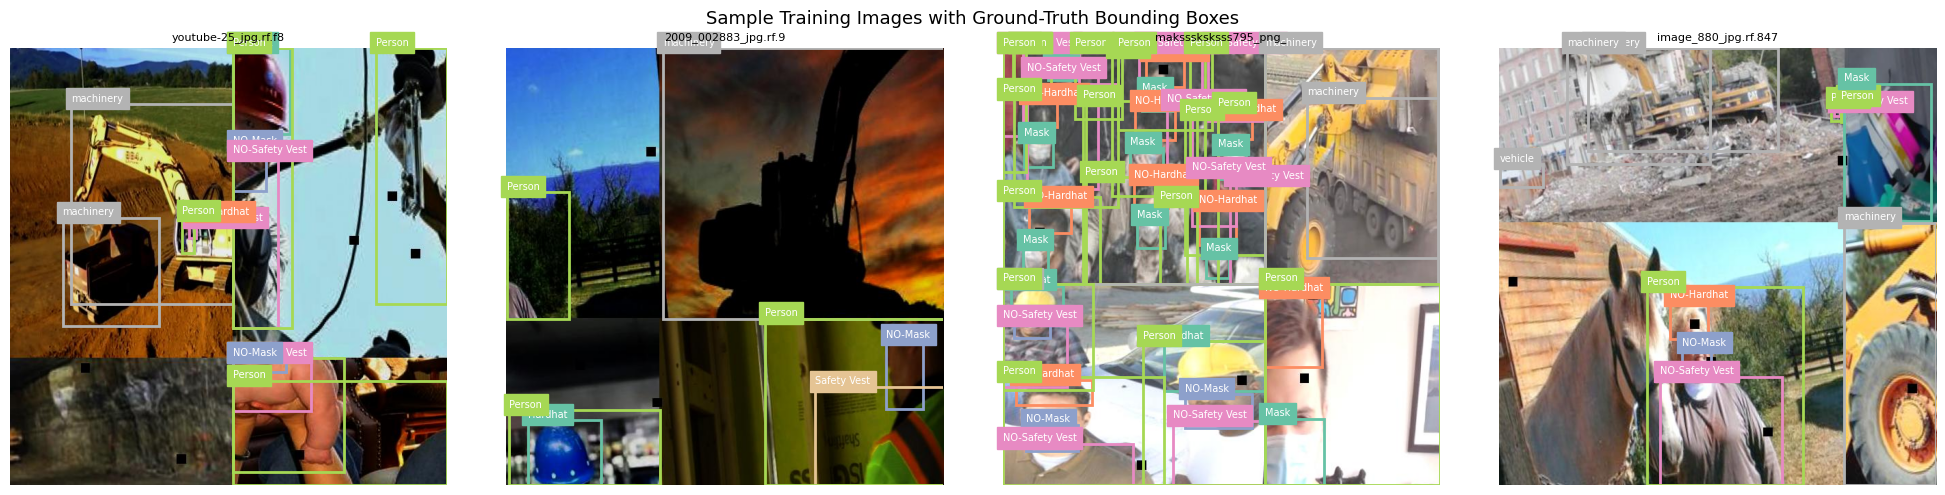

✅ Dataset inspection complete.


In [5]:
import yaml
import os
from pathlib import Path
from ultralytics.utils.plotting import Annotator
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import random

# ── 1. Read data.yaml ──────────────────────────────────────────────────────────
yaml_path = Path(dataset.location) / 'data.yaml'
with open(yaml_path, 'r') as f:
    data_cfg = yaml.safe_load(f)

print('=== data.yaml contents ===')
print(f'Classes ({data_cfg["nc"]}):', data_cfg['names'])
print()

# ── 2. Count images per split ──────────────────────────────────────────────────
for split in ['train', 'valid', 'test']:
    split_path = Path(dataset.location) / split / 'images'
    if split_path.exists():
        count = len(list(split_path.glob('*.*')))
        print(f'{split:6s} images: {count}')
    else:
        print(f'{split:6s} images: folder not found')

# ── 3. Display 4 sample images with bounding boxes ────────────────────────────
train_img_dir   = Path(dataset.location) / 'train' / 'images'
train_label_dir = Path(dataset.location) / 'train' / 'labels'
class_names     = data_cfg['names']

# Pick 4 random images that have a matching label file
all_imgs = list(train_img_dir.glob('*.jpg')) + list(train_img_dir.glob('*.png'))
sample_imgs = random.sample(all_imgs, min(4, len(all_imgs)))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Sample Training Images with Ground-Truth Bounding Boxes', fontsize=13)

# Colour palette for each class
colours = plt.cm.get_cmap('Set2', len(class_names))

for ax, img_path in zip(axes, sample_imgs):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV loads BGR; convert to RGB
    h, w = img.shape[:2]
    ax.imshow(img)

    # Read YOLO label file (same name, .txt extension)
    label_path = train_label_dir / (img_path.stem + '.txt')
    if label_path.exists():
        with open(label_path) as lf:
            for line in lf:
                parts = line.strip().split()
                cls_id = int(parts[0])
                # YOLO format: cx cy w h (all normalised 0-1)
                cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                # Convert to pixel top-left corner
                x1 = (cx - bw / 2) * w
                y1 = (cy - bh / 2) * h
                rect = patches.Rectangle(
                    (x1, y1), bw * w, bh * h,
                    linewidth=2,
                    edgecolor=colours(cls_id),
                    facecolor='none'
                )
                ax.add_patch(rect)
                ax.text(
                    x1, y1 - 4,
                    class_names[cls_id],
                    color='white',
                    fontsize=7,
                    backgroundcolor=colours(cls_id)
                )
    ax.axis('off')
    ax.set_title(img_path.name[:20], fontsize=8)

plt.tight_layout()
plt.savefig('/content/sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Dataset inspection complete.')

## Cell 5 — Train YOLOv8-nano

### Hyperparameter explanation

| Parameter | Value | Why |
|-----------|-------|-----|
| `model` | yolov8n.pt | Nano = fastest inference; ideal for edge laptop cam |
| `epochs` | 60 | More headroom than default 50 without excessive Colab time |
| `imgsz` | 640 | Standard resolution; good balance of accuracy vs speed |
| `batch` | 16 / 8 | Auto-set by VRAM check above |
| `optimizer` | AdamW | Better convergence than SGD on small datasets |
| `patience` | 15 | Tolerate 15 flat epochs before early stopping |
| `mosaic` | 1.0 | Mosaic augmentation — great for small object detection |
| `cache` | True | Caches images in RAM → faster epochs after the first |
| `save_period` | 10 | Saves checkpoint every 10 epochs — protects against disconnects |
| `device` | 0 | Use GPU (index 0) |

> ⏱️ Expected time on T4: **25–40 minutes**. Do not close the browser tab.

In [6]:
from ultralytics import YOLO

# Load the pretrained YOLOv8-nano base model (downloads ~6MB on first run)
model = YOLO('yolov8n.pt')

# Train — all key hyperparameters explicitly set
results = model.train(
    data      = f'{dataset.location}/data.yaml',  # path to dataset config
    epochs    = 60,          # total training epochs
    imgsz     = 640,         # input image resolution
    batch     = BATCH_SIZE,  # auto-set to 16 or 8 based on VRAM
    optimizer = 'AdamW',     # optimiser — better convergence than SGD here
    lr0       = 0.001,       # initial learning rate
    patience  = 15,          # early stop if no mAP improvement for 15 epochs
    mosaic    = 1.0,         # mosaic data augmentation (0-1 probability)
    hsv_h     = 0.015,       # hue augmentation
    hsv_s     = 0.7,         # saturation augmentation
    hsv_v     = 0.4,         # value/brightness augmentation
    flipud    = 0.1,         # vertical flip probability (rare but helps)
    cache     = True,        # cache images in RAM for faster subsequent epochs
    save      = True,        # save best.pt and last.pt
    save_period = 10,        # checkpoint every 10 epochs (disconnect recovery)
    name      = 'drishti_ppe',  # results saved to runs/detect/drishti_ppe/
    device    = 0,           # GPU index 0
    workers   = 2,           # data loader workers (keep low on Colab)
    verbose   = True         # print per-epoch stats
)

print('\n✅ Training complete.')
print(f'Results saved to: runs/detect/drishti_ppe/')

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Construction-Site-Safety-27/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=drishti_ppe, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mas

## Cell 5b — Resume Training (run ONLY if Colab disconnected mid-training)

If your session died partway through, run this cell instead of re-running Cell 5.  
It picks up from the last saved checkpoint automatically.

In [ ]:
# ── RESUME CELL — only run this if training was interrupted ──────────────────
# Skip this cell if Cell 5 completed successfully.

from ultralytics import YOLO

# Load the last checkpoint (not best.pt — last.pt has the optimiser state)
resume_model = YOLO('runs/detect/drishti_ppe/weights/last.pt')

# Resume = True tells YOLO to continue from where it stopped
resume_results = resume_model.train(resume=True)

print('✅ Training resumed and completed.')

## Cell 6 — Plot Training Curves

Reads `results.csv` generated during training and plots:
- **Loss curves** (box loss, classification loss, DFL loss) — should trend downward
- **mAP curves** (mAP50, mAP50-95) — should trend upward and plateau

Available columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


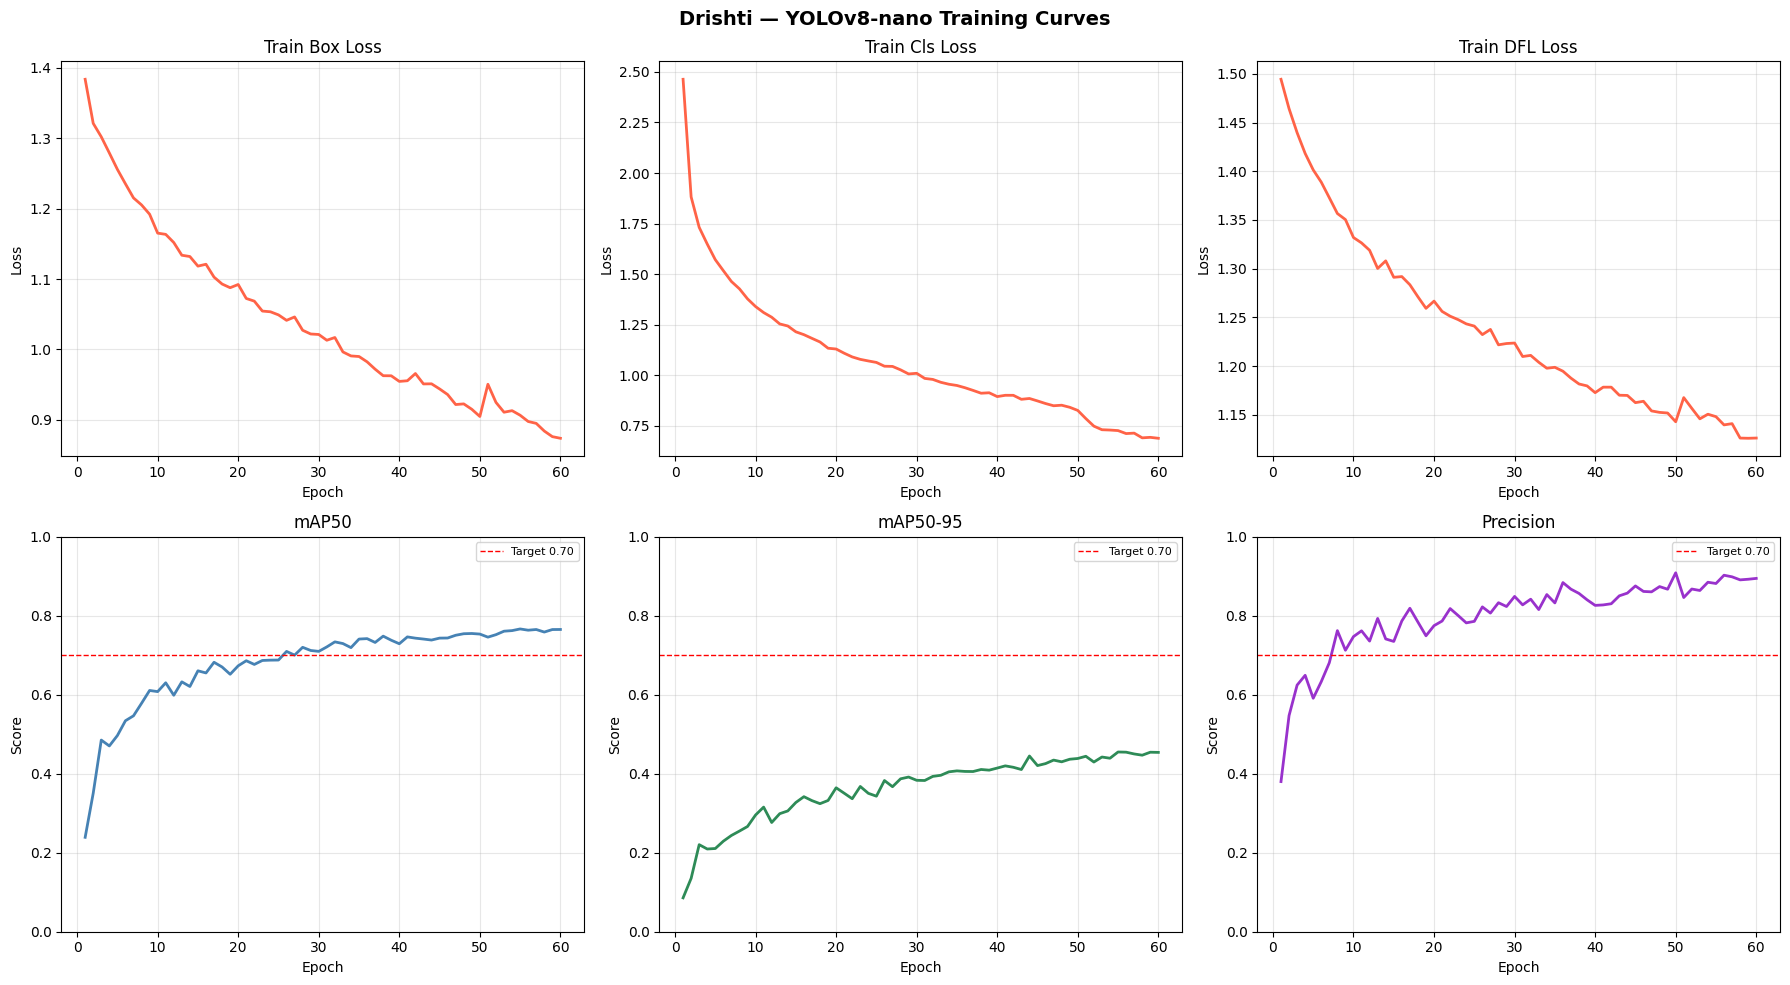

✅ Training curves saved to /content/training_curves.png


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the training log CSV produced by Ultralytics
results_csv = 'runs/detect/drishti_ppe/results.csv'
df = pd.read_csv(results_csv)

# Strip whitespace from column names (Ultralytics sometimes adds spaces)
df.columns = df.columns.str.strip()
print('Available columns:', df.columns.tolist())

epochs = df['epoch']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Drishti — YOLOv8-nano Training Curves', fontsize=14, fontweight='bold')

# ── Loss plots (should trend downward) ────────────────────────────────────────
loss_cols = [
    ('train/box_loss',  'Train Box Loss',   axes[0][0]),
    ('train/cls_loss',  'Train Cls Loss',   axes[0][1]),
    ('train/dfl_loss',  'Train DFL Loss',   axes[0][2]),
]
for col, title, ax in loss_cols:
    if col in df.columns:
        ax.plot(epochs, df[col], color='tomato', linewidth=2)
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.grid(True, alpha=0.3)

# ── mAP plots (should trend upward) ───────────────────────────────────────────
map_cols = [
    ('metrics/mAP50(B)',    'mAP50',       axes[1][0], 'steelblue'),
    ('metrics/mAP50-95(B)', 'mAP50-95',   axes[1][1], 'seagreen'),
    ('metrics/precision(B)','Precision',   axes[1][2], 'darkorchid'),
]
for col, title, ax, color in map_cols:
    if col in df.columns:
        ax.plot(epochs, df[col], color=color, linewidth=2)
        ax.axhline(y=0.70, color='red', linestyle='--', linewidth=1, label='Target 0.70')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Score')
        ax.set_ylim(0, 1)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Training curves saved to /content/training_curves.png')

## Cell 7 — Evaluate Model

### What these metrics mean

| Metric | What it measures | Target |
|--------|-----------------|--------|
| **mAP50** | Detection accuracy at IoU ≥ 0.50 (standard threshold) | > 0.70 |
| **mAP50-95** | Average accuracy across IoU thresholds 0.50–0.95 (stricter) | > 0.45 |
| **Precision** | Of all detections made, how many were correct | > 0.70 |
| **Recall** | Of all actual violations, how many did the model catch | > 0.65 |

> If mAP50 < 0.60: go back to Cell 5 and increase `epochs` to 75, then re-run.

In [8]:
from ultralytics import YOLO

# Load the best weights (not the model object from training — fresh load catches bugs)
eval_model = YOLO('runs/detect/drishti_ppe/weights/best.pt')

# Run validation on the validation split
metrics = eval_model.val(
    data    = f'{dataset.location}/data.yaml',
    imgsz   = 640,
    device  = 0
)

# ── Extract key metrics ────────────────────────────────────────────────────────
map50    = metrics.box.map50   # mAP at IoU 0.50
map5095  = metrics.box.map     # mAP at IoU 0.50:0.95
precision = metrics.box.mp    # mean precision
recall    = metrics.box.mr    # mean recall

# ── Print formatted results ────────────────────────────────────────────────────
print('\n' + '='*45)
print('       DRISHTI MODEL EVALUATION RESULTS')
print('='*45)
print(f'  mAP50      : {map50:.4f}   (target > 0.70)')
print(f'  mAP50-95   : {map5095:.4f}  (target > 0.45)')
print(f'  Precision  : {precision:.4f}  (target > 0.70)')
print(f'  Recall     : {recall:.4f}  (target > 0.65)')
print('='*45)

# ── Pass/fail check ────────────────────────────────────────────────────────────
if map50 >= 0.70:
    print(f'\n✅ mAP50 PASSED: {map50:.4f} ≥ 0.70')
elif map50 >= 0.60:
    print(f'\n⚠️  mAP50 MARGINAL: {map50:.4f} — consider increasing epochs to 75')
else:
    print(f'\n❌ mAP50 FAILED: {map50:.4f} < 0.60 — retrain with epochs=75 or try dataset v3')

# Store for use in training report cell
EVAL_METRICS = {
    'map50': map50, 'map5095': map5095,
    'precision': precision, 'recall': recall
}

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1272.9±462.6 MB/s, size: 51.7 KB)
val: Scanning /content/Construction-Site-Safety-27/valid/labels.cache... 114 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 114/114 25.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.1it/s 3.8s
                   all        114        697      0.881      0.696      0.767      0.455
               Hardhat         42         79      0.968      0.776      0.843      0.503
                  Mask         19         21      0.961       0.81      0.874      0.615
            NO-Hardhat         37         69      0.819      0.551      0.652      0.347
               NO-Mask         44         74      0.822      0.561      0.642      0.293
        NO-Safety Vest        

## Cell 8 — Run Inference on Sample Validation Images

Loads `best.pt` and runs detection on 3 validation images.  
Displays bounding boxes and confidence scores to visually confirm the model works.


0: 640x640 2 Hardhats, 2 NO-Safety Vests, 6 Persons, 12.8ms
1: 640x640 1 Mask, 1 NO-Safety Vest, 1 Person, 12.8ms
2: 640x640 1 Hardhat, 1 NO-Mask, 1 NO-Safety Vest, 1 Person, 12.8ms
Speed: 2.2ms preprocess, 12.8ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/inference_samples


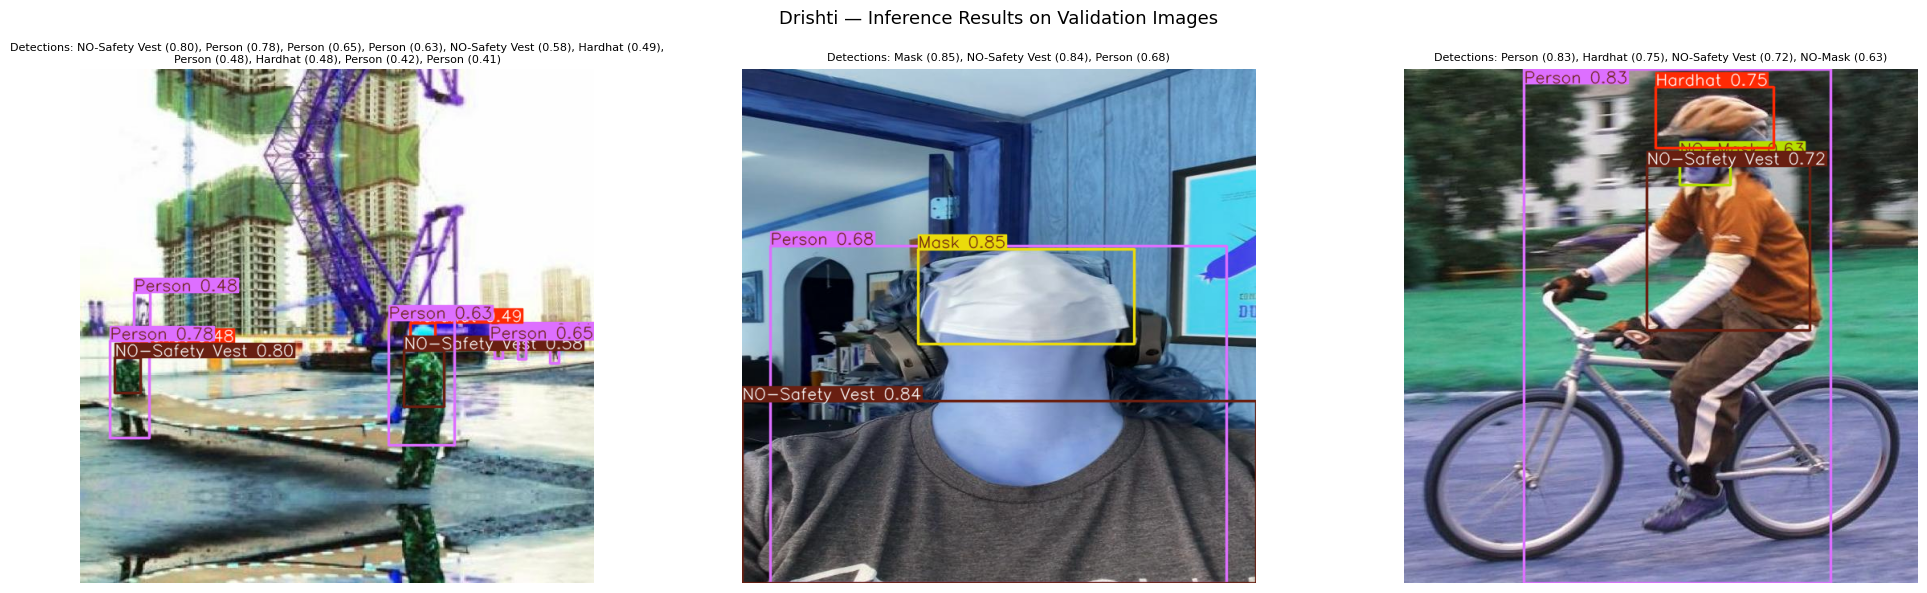

✅ Inference complete. Annotated images saved to /content/inference_samples/


In [9]:
from ultralytics import YOLO
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Load best model for inference
infer_model = YOLO('runs/detect/drishti_ppe/weights/best.pt')

# Pick 3 random images from the validation set
val_img_dir = Path(dataset.location) / 'valid' / 'images'
val_imgs    = list(val_img_dir.glob('*.jpg')) + list(val_img_dir.glob('*.png'))
sample_3    = random.sample(val_imgs, min(3, len(val_imgs)))

# Run inference — save_dir stores annotated images
infer_results = infer_model.predict(
    source     = [str(p) for p in sample_3],
    imgsz      = 640,
    conf       = 0.35,          # confidence threshold: only show detections ≥ 35%
    iou        = 0.45,          # NMS IoU threshold
    save       = True,          # save annotated images
    project    = '/content',
    name       = 'inference_samples',
    exist_ok   = True
)

# ── Display annotated results ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Drishti — Inference Results on Validation Images', fontsize=13)

for i, (result, ax) in enumerate(zip(infer_results, axes)):
    # Plot the annotated image from result object
    annotated = result.plot()          # returns RGB numpy array
    ax.imshow(annotated)
    ax.axis('off')

    # Print detections below the image
    boxes = result.boxes
    if boxes is not None and len(boxes) > 0:
        det_str = ', '.join([
            f'{infer_model.names[int(c)]} ({float(conf):.2f})'
            for c, conf in zip(boxes.cls, boxes.conf)
        ])
        ax.set_title(f'Detections: {det_str}', fontsize=8, wrap=True)
    else:
        ax.set_title('No detections', fontsize=8)

plt.tight_layout()
plt.savefig('/content/inference_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Inference complete. Annotated images saved to /content/inference_samples/')

## Cell 9 — Export best.pt

Copies `best.pt` to `/content/` and downloads it to your Windows machine.  
Place this file at `drishti/training/best.pt` in the team repo — this is the exact path Member 2's `inference.py` expects.

In [10]:
import shutil
import os
from pathlib import Path
from google.colab import files

# Source path — where Ultralytics saves the best weights after training
src = Path('runs/detect/drishti_ppe/weights/best.pt')

# Destination — root of Colab filesystem for easy download
dst = Path('/content/best.pt')

# Verify the source file exists before copying
if not src.exists():
    raise FileNotFoundError(
        f'❌ best.pt not found at {src}. Did training complete successfully?'
    )

# Copy to /content/
shutil.copy(str(src), str(dst))

# Get file size
size_mb = dst.stat().st_size / 1e6
print(f'✅ best.pt copied to {dst}')
print(f'   File size: {size_mb:.2f} MB')

# Note for Git LFS
if size_mb > 100:
    print('⚠️  File > 100 MB — you need Git LFS to push to GitHub.')
    print('   Run: git lfs track "training/best.pt" before git add')

# Download to local machine
print('\n⬇️  Downloading best.pt to your machine...')
files.download('/content/best.pt')
print('✅ Download triggered.')

✅ best.pt copied to /content/best.pt
   File size: 6.25 MB

⬇️  Downloading best.pt to your machine...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download triggered.


## Cell 10 — Training Report

Prints the formatted summary to copy into `training_report.txt`  
and also saves it directly to `/content/training_report.txt` for download.

In [11]:
import yaml
from pathlib import Path
from google.colab import files

# Read class names from data.yaml
yaml_path = Path(dataset.location) / 'data.yaml'
with open(yaml_path) as f:
    data_cfg = yaml.safe_load(f)
class_names = ', '.join(data_cfg['names'])

# Pull metrics from EVAL_METRICS dict (set in Cell 7)
# If you skipped Cell 7, re-run it first
m = EVAL_METRICS

report = f"""==============================================
 DRISHTI — YOLOv8 Training Report
 Hackathon: Tata Technologies InnoVent 2026
==============================================

Dataset        : Hard Hat Workers (Roboflow Universe)
                 Workspace : roboflow-universe-projects
                 Project   : hard-hat-sample  |  Version: 2

Model          : YOLOv8-nano (yolov8n.pt base)
Epochs         : 60 (early stop patience = 15)
Image Size     : 640 x 640
Batch Size     : {BATCH_SIZE}
Optimizer      : AdamW  |  lr0 = 0.001
Augmentations  : mosaic=1.0, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, flipud=0.1

── Results ────────────────────────────────
mAP50          : {m['map50']:.4f}   (target > 0.70)
mAP50-95       : {m['map5095']:.4f}  (target > 0.45)
Precision      : {m['precision']:.4f}  (target > 0.70)
Recall         : {m['recall']:.4f}  (target > 0.65)

Classes        : {class_names}
                 (Key violation classes: NO-Hardhat, NO-Safety Vest, NO-Mask)

── Output Files ───────────────────────────
best.pt        : training/best.pt
Notebook       : training/drishti_training.ipynb
==============================================
"""

# Print to notebook output
print(report)

# Save to file
report_path = '/content/training_report.txt'
with open(report_path, 'w') as f:
    f.write(report)

print(f'✅ Report saved to {report_path}')

# Download to local machine
files.download(report_path)
print('⬇️  Downloading training_report.txt...')

 DRISHTI — YOLOv8 Training Report
 Hackathon: Tata Technologies InnoVent 2026

Dataset        : Hard Hat Workers (Roboflow Universe)
                 Workspace : roboflow-universe-projects
                 Project   : hard-hat-sample  |  Version: 2

Model          : YOLOv8-nano (yolov8n.pt base)
Epochs         : 60 (early stop patience = 15)
Image Size     : 640 x 640
Batch Size     : 16
Optimizer      : AdamW  |  lr0 = 0.001
Augmentations  : mosaic=1.0, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, flipud=0.1

── Results ────────────────────────────────
mAP50          : 0.7672   (target > 0.70)
mAP50-95       : 0.4552  (target > 0.45)
Precision      : 0.8815  (target > 0.70)
Recall         : 0.6957  (target > 0.65)

Classes        : Hardhat, Mask, NO-Hardhat, NO-Mask, NO-Safety Vest, Person, Safety Cone, Safety Vest, machinery, vehicle
                 (Key violation classes: NO-Hardhat, NO-Safety Vest, NO-Mask)

── Output Files ───────────────────────────
best.pt        : training/best.pt
Noteb

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloading training_report.txt...


## ✅ You're Done — Checklist

Before opening your PR:

- [ ] `best.pt` downloaded from Colab
- [ ] `training_report.txt` downloaded from Colab
- [ ] Both files placed in `drishti/training/`
- [ ] Notebook saved as `drishti/training/drishti_training.ipynb`
- [ ] If `best.pt` > 100MB: `git lfs track "training/best.pt"` run first
- [ ] `git add`, `git commit`, `git push origin feature/member1-training`
- [ ] Pull Request opened and team leader tagged

---

**What Member 2 needs from you:**  
`training/best.pt` — exact path, exact filename. Do not rename it.

---
*Drishti | Tata Technologies InnoVent 2026 | ML Engineer: Arnav*